# Hierarchical Clustering
# E-Commerce Customer Behavior and Sales Analysis

## Project Overview

In today’s e-commerce industry, understanding customer behavior is one of the most important factors for improving business performance, increasing revenue, and building effective marketing strategies. Companies generate massive amounts of transactional and behavioral data every day, but transforming this raw data into actionable insights requires advanced data analysis and machine learning techniques.

This project focuses on analyzing the **E-Commerce Customer Behavior and Sales Analysis TR** dataset to discover hidden customer patterns, purchasing behaviors, and engagement characteristics using **unsupervised machine learning techniques**, particularly **Customer Segmentation with Clustering**.

The main objective of this project is to identify different types of customers based on:

* Purchasing behavior
* Spending patterns
* Order frequency
* Customer engagement
* Website interaction
* Customer satisfaction

To achieve this, the project applies a complete data science workflow including:

* Data Cleaning and Preprocessing
* Exploratory Data Analysis
* Feature Engineering
* Customer-Level Aggregation
* Scaling and Transformation Techniques
* Clustering Analysis using K-Means
* Cluster Evaluation Metrics
* Customer Cohort Analysis and Segmentation

Several clustering experiments were conducted using different preprocessing strategies, feature combinations, scalers, and numbers of clusters. The project compares these experiments using multiple evaluation metrics such as:

* Silhouette Score
* Davies-Bouldin Score
* Calinski-Harabasz Score

A major focus of this project is separating customers into two important dimensions:

1. **Customer Value**

   * Total spending
   * Order frequency
   * Average order value

2. **Customer Engagement**

   * Session duration
   * Pages viewed
   * Customer ratings

This approach allows the creation of highly meaningful customer segments that can help businesses:

* Improve customer retention
* Design personalized marketing campaigns
* Identify high-value customers
* Detect low-engagement customers
* Optimize sales strategies
* Increase customer satisfaction

By the end of this project, the dataset is transformed into a powerful customer intelligence framework that provides clear business insights and actionable segmentation strategies for real-world e-commerce applications.

---

## Dataset

The dataset used in this project is E-Commerce Customer Behavior & Sales dataset
Dataset Source:  
[Kaggle - E-Commerce Customer Behavior & Sales Analysis -TR Dataset](https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr)

---

## Project Goal

The primary goal of this project is to build a robust customer segmentation system that groups customers based on both purchasing power and engagement behavior in order to generate meaningful business insights and support data-driven decision-making.

---

## Technologies and Libraries Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn

---

## Machine Learning Technique

* Unsupervised Learning

  * Hierarchical Clustering

---

## Evaluation Metrics

* Silhouette Score
* Davies-Bouldin Score
* Calinski-Harabasz Score

---

## Final Outcome

The final clustering framework successfully identifies multiple customer segments by combining customer value analysis with engagement analysis, enabling deeper understanding of customer behavior and supporting advanced business and marketing strategies.


# **Importing the Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# **Data preprocessing**

## Data Cleaning Check Template
This template is designed to quickly assess the quality of any dataset before building machine learning models or performing analysis.

It provides a structured overview of the dataset by checking for common data issues such as:

- Missing values

- Duplicate rows

- Incorrect data types

- Outliers

- Distribution of numerical features

- Categorical feature consistency

**What This Template Does**

- Displays basic dataset information (shape, data types)

- Identifies missing values and duplicates

- Summarizes numerical and categorical features

- Detects potential outliers using the IQR method

- Highlights columns with low unique values for quick inspection

How to Use

1. Load your dataset using Pandas  

2. Call the function:

In [2]:
def data_quality_report(df):

    print("DATA QUALITY REPORT")
    
    # Print a separator line for better readability
    
    print("=" * 50)
    print("BASIC INFO")
    print("=" * 50)
    
    # Show general information about the dataset (columns, data types, non-null values)
    print(df.info())
    
    # Show number of rows and columns
    print("\n" + "=" * 50)
    print("SHAPE OF DATA")
    print("=" * 50)
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    # Check for missing (null) values in each column
    print("\n" + "=" * 50)
    print("MISSING VALUES")
    print("=" * 50)
    missing = df.isnull().sum()
    
    # Display only columns that have missing values
    print(missing[missing > 0])
    
    # Check for duplicate rows
    print("\n" + "=" * 50)
    print("DUPLICATES")
    print("=" * 50)
    print(f"Duplicate rows: {df.duplicated().sum()}")
    
    # Display data types of each column
    print("\n" + "=" * 50)
    print("DATA TYPES")
    print("=" * 50)
    print(df.dtypes)
    
    # Summary statistics for numerical columns (mean, std, min, max, etc.)
    print("\n" + "=" * 50)
    print("NUMERICAL SUMMARY")
    print("=" * 50)
    print(df.describe())
    
    # Summary for categorical (object) columns
    print("\n" + "=" * 50)
    print("CATEGORICAL SUMMARY")
    print("=" * 50)
    print(df.describe(include=['object']))
    
    # Show unique values for columns with low number of distinct values
    # Useful for detecting categories, errors, or inconsistencies
    print("\n" + "=" * 50)
    print("UNIQUE VALUES (LOW CARDINALITY)")
    print("=" * 50)
    for col in df.columns:
        if df[col].nunique() < 10:  # Only show columns with few unique values
            print(f"{col}: {df[col].unique()}")
            
    # correlation
    print("\n" + "=" * 50)
    print("CORRELATION MATRIX")
    print("=" * 50)
    print(df.corr(numeric_only=True))
    
    # Detect outliers using the IQR (Interquartile Range) method
    print("\n" + "=" * 50)
    print("OUTLIERS CHECK (IQR METHOD)")
    print("=" * 50)
    
    # Loop through only numerical columns
    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)  # 25th percentile
        Q3 = df[col].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range
        
        # Count rows that fall outside the normal range
        outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
        print(f"{col}: {len(outliers)} outliers")

# **Load dataset**
Apply Data Cleaning Check Template

In [ ]:
dataset = pd.read_csv("ecommerce_customer_behavior_dataset_v2.csv")
data_quality_report(dataset)

DATA QUALITY REPORT
BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  1704

# Transforming Transactional Data into Customer-Level Metrics

In [4]:
dataset['Date'] = pd.to_datetime(dataset['Date'])
reference_date = dataset['Date'].max()
recency_df = dataset.groupby('Customer_ID').agg({'Date':'max'})
recency_df['Recency_Days'] = (reference_date - recency_df['Date']).dt.days

customer_df = dataset.groupby('Customer_ID').agg({

    # Spending Behavior
    'Total_Amount':'sum',
    'Quantity':'sum',
    'Unit_Price':'mean',
    'Discount_Amount':'mean',

    # Frequency
    'Order_ID':'count',

    # Engagement
    'Session_Duration_Minutes':'mean',
    'Pages_Viewed':'mean',

    # Satisfaction
    'Customer_Rating':'mean',

    # Logistics
    'Delivery_Time_Days':'mean',

    # Customer Info
    'Age':'first',

    # Boolean
    'Is_Returning_Customer':'mean'

})

print(customer_df)

             Total_Amount  Quantity  Unit_Price  Discount_Amount  Order_ID  \
Customer_ID                                                                  
CUST_00001        2199.63         7  335.466667        46.016667         3   
CUST_00002         809.90         8  123.725000        35.525000         2   
CUST_00003        3030.81         7  362.565000         0.000000         2   
CUST_00004         383.22         5   96.200000        97.780000         1   
CUST_00005        2422.73         8  378.736667         0.000000         3   
...                   ...       ...         ...              ...       ...   
CUST_04996        3001.96        13  238.072500         0.000000         4   
CUST_04997       15440.42        13  945.147500         1.905000         4   
CUST_04998         482.90         5   96.580000         0.000000         1   
CUST_04999         137.30         2   68.650000         0.000000         1   
CUST_05000        7282.41        10  571.080000        56.452500

## Renaming Columns for Analytical Clarity

In [5]:
customer_df.rename(columns={'Order_ID':'Num_Orders'}, inplace=True)
print(customer_df)

             Total_Amount  Quantity  Unit_Price  Discount_Amount  Num_Orders  \
Customer_ID                                                                    
CUST_00001        2199.63         7  335.466667        46.016667           3   
CUST_00002         809.90         8  123.725000        35.525000           2   
CUST_00003        3030.81         7  362.565000         0.000000           2   
CUST_00004         383.22         5   96.200000        97.780000           1   
CUST_00005        2422.73         8  378.736667         0.000000           3   
...                   ...       ...         ...              ...         ...   
CUST_04996        3001.96        13  238.072500         0.000000           4   
CUST_04997       15440.42        13  945.147500         1.905000           4   
CUST_04998         482.90         5   96.580000         0.000000           1   
CUST_04999         137.30         2   68.650000         0.000000           1   
CUST_05000        7282.41        10  571

## Merging Recency Metrics into the Customer Profile

In [6]:
customer_df = customer_df.merge(recency_df[['Recency_Days']], left_index=True, right_index=True)
print(customer_df)

             Total_Amount  Quantity  Unit_Price  Discount_Amount  Num_Orders  \
Customer_ID                                                                    
CUST_00001        2199.63         7  335.466667        46.016667           3   
CUST_00002         809.90         8  123.725000        35.525000           2   
CUST_00003        3030.81         7  362.565000         0.000000           2   
CUST_00004         383.22         5   96.200000        97.780000           1   
CUST_00005        2422.73         8  378.736667         0.000000           3   
...                   ...       ...         ...              ...         ...   
CUST_04996        3001.96        13  238.072500         0.000000           4   
CUST_04997       15440.42        13  945.147500         1.905000           4   
CUST_04998         482.90         5   96.580000         0.000000           1   
CUST_04999         137.30         2   68.650000         0.000000           1   
CUST_05000        7282.41        10  571

## Derived Behavioral Feature Calculation

In [7]:
customer_df['Avg_Order_Value'] = (customer_df['Total_Amount'] / customer_df['Num_Orders'])

customer_df['Basket_Size'] = (customer_df['Quantity'] / customer_df['Num_Orders'])

customer_df['Pages_Per_Minute'] = (customer_df['Pages_Viewed'] / customer_df['Session_Duration_Minutes'])

diversity_df = dataset.groupby('Customer_ID')['Product_Category'].nunique()

customer_df['Product_Diversity'] = diversity_df

print(customer_df)

             Total_Amount  Quantity  Unit_Price  Discount_Amount  Num_Orders  \
Customer_ID                                                                    
CUST_00001        2199.63         7  335.466667        46.016667           3   
CUST_00002         809.90         8  123.725000        35.525000           2   
CUST_00003        3030.81         7  362.565000         0.000000           2   
CUST_00004         383.22         5   96.200000        97.780000           1   
CUST_00005        2422.73         8  378.736667         0.000000           3   
...                   ...       ...         ...              ...         ...   
CUST_04996        3001.96        13  238.072500         0.000000           4   
CUST_04997       15440.42        13  945.147500         1.905000           4   
CUST_04998         482.90         5   96.580000         0.000000           1   
CUST_04999         137.30         2   68.650000         0.000000           1   
CUST_05000        7282.41        10  571

## Feature Selection: Isolating the Financial Value Stream

In [8]:
value_cols = ['Total_Amount', 'Discount_Amount', 'Quantity', 'Num_Orders', 'Avg_Order_Value']
df_value = customer_df[value_cols].copy()
print(df_value)

             Total_Amount  Discount_Amount  Quantity  Num_Orders  \
Customer_ID                                                        
CUST_00001        2199.63        46.016667         7           3   
CUST_00002         809.90        35.525000         8           2   
CUST_00003        3030.81         0.000000         7           2   
CUST_00004         383.22        97.780000         5           1   
CUST_00005        2422.73         0.000000         8           3   
...                   ...              ...       ...         ...   
CUST_04996        3001.96         0.000000        13           4   
CUST_04997       15440.42         1.905000        13           4   
CUST_04998         482.90         0.000000         5           1   
CUST_04999         137.30         0.000000         2           1   
CUST_05000        7282.41        56.452500        10           4   

             Avg_Order_Value  
Customer_ID                   
CUST_00001        733.210000  
CUST_00002        404.

## Feature Selection: Isolating the Digital Engagement Stream

In [9]:
engagement_cols = ['Session_Duration_Minutes', 'Pages_Viewed', 'Pages_Per_Minute', 'Customer_Rating']

df_engagement = customer_df[engagement_cols].copy()

print(df_engagement)

             Session_Duration_Minutes  Pages_Viewed  Pages_Per_Minute  \
Customer_ID                                                             
CUST_00001                  14.333333      9.000000          0.627907   
CUST_00002                  15.000000     10.000000          0.666667   
CUST_00003                  10.500000      8.500000          0.809524   
CUST_00004                  16.000000     15.000000          0.937500   
CUST_00005                  12.666667      9.333333          0.736842   
...                               ...           ...               ...   
CUST_04996                  14.750000      7.500000          0.508475   
CUST_04997                  15.500000     11.250000          0.725806   
CUST_04998                   9.000000      8.000000          0.888889   
CUST_04999                  14.000000     10.000000          0.714286   
CUST_05000                  15.000000      9.250000          0.616667   

             Customer_Rating  
Customer_ID        

## Data Extraction: Converting Value Features to NumPy Arrays

In [10]:
X_1 = df_value.iloc[:,:].values
print(X_1[0:10, :])

[[2.19963000e+03 4.60166667e+01 7.00000000e+00 3.00000000e+00
  7.33210000e+02]
 [8.09900000e+02 3.55250000e+01 8.00000000e+00 2.00000000e+00
  4.04950000e+02]
 [3.03081000e+03 0.00000000e+00 7.00000000e+00 2.00000000e+00
  1.51540500e+03]
 [3.83220000e+02 9.77800000e+01 5.00000000e+00 1.00000000e+00
  3.83220000e+02]
 [2.42273000e+03 0.00000000e+00 8.00000000e+00 3.00000000e+00
  8.07576667e+02]
 [1.24583000e+03 4.25666667e+00 9.00000000e+00 3.00000000e+00
  4.15276667e+02]
 [1.33155000e+03 1.42950000e+02 5.00000000e+00 1.00000000e+00
  1.33155000e+03]
 [5.60229000e+03 6.33833333e+01 6.00000000e+00 3.00000000e+00
  1.86743000e+03]
 [4.70860000e+02 0.00000000e+00 2.00000000e+00 1.00000000e+00
  4.70860000e+02]
 [1.42116000e+03 0.00000000e+00 1.00000000e+01 3.00000000e+00
  4.73720000e+02]]


In [11]:
print(f"Rows: {X_1.shape[0]}, Columns: {X_1.shape[1]}")

Rows: 5000, Columns: 5


## Data Extraction: Converting Engagement Features to NumPy Arrays

In [12]:
X_2 = df_engagement.iloc[:,:].values
print(X_2[0:10, :])

[[14.33333333  9.          0.62790698  3.33333333]
 [15.         10.          0.66666667  4.        ]
 [10.5         8.5         0.80952381  3.5       ]
 [16.         15.          0.9375      5.        ]
 [12.66666667  9.33333333  0.73684211  3.66666667]
 [16.          9.33333333  0.58333333  4.33333333]
 [17.          9.          0.52941176  4.        ]
 [17.          9.          0.52941176  4.66666667]
 [11.         11.          1.          3.        ]
 [14.33333333  9.          0.62790698  4.        ]]


In [13]:
print(f"Rows: {X_2.shape[0]}, Columns: {X_2.shape[1]}")

Rows: 5000, Columns: 4


# Feature Scaling and Pipeline Transformation

> **Note on Methodology:** The foundational concepts of Robust Scaling, including mathematical resistance to extreme outliers via interquartile ranges, were explained comprehensively in the previous leave section of the project roadmap. For a deep dive into why this specific scaler was chosen over standard normalization, please refer to the [StandardScaler vs RobustScaler (PDF)](https://github.com/Hazem1695/ml-concept-briefs).


## Robust Feature Scaling: Financial Value Stream (X_1)

In [14]:
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()
X_1 = rs.fit_transform(X_1)

In [15]:
print(X_1[0:10, :])

[[-0.0599759   0.39560518 -0.22222222  0.         -0.05265819]
 [-0.34319617  0.24565729 -0.11111111 -0.33333333 -0.33477191]
 [ 0.10941457 -0.26206938 -0.22222222 -0.33333333  0.61957705]
 [-0.4301515   1.13541164 -0.44444444 -0.66666667 -0.35344714]
 [-0.0145092  -0.26206938 -0.11111111  0.          0.01125413]
 [-0.25435574 -0.20123269  0.          0.         -0.32589695]
 [-0.23688642  1.78098556 -0.44444444 -0.66666667  0.4615681 ]
 [ 0.63346979  0.64381123 -0.33333333  0.          0.92211492]
 [-0.41229089 -0.26206938 -0.77777778 -0.66666667 -0.27812744]
 [-0.21862433 -0.26206938  0.11111111  0.         -0.27566949]]


## Robust Feature Scaling: Digital Engagement Stream (X_2)

In [16]:
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()
X_2 = rs.fit_transform(X_2)

In [17]:
print(X_2[0:10, :])

[[-0.07073386  0.          0.06874374 -0.66666667]
 [ 0.21220159  0.5         0.31539632  0.        ]
 [-1.69761273 -0.25        1.22448723 -0.5       ]
 [ 0.63660477  3.          2.03888117  1.        ]
 [-0.7780725   0.16666667  0.76196729 -0.33333333]
 [ 0.63660477  0.16666667 -0.21490671  0.33333333]
 [ 1.06100796  0.         -0.55804397  0.        ]
 [ 1.06100796  0.         -0.55804397  0.66666667]
 [-1.48541114  1.          2.43660844 -1.        ]
 [-0.07073386  0.          0.06874374  0.        ]]


# Determining Optimal Clusters for Purchasing Power (X_1)

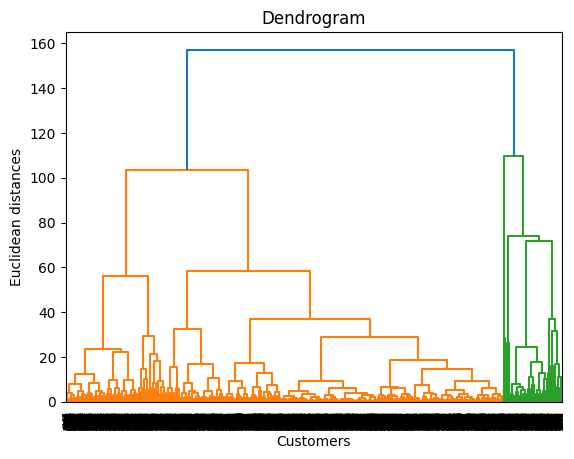

In [18]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X_1, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

# Determining Optimal Clusters for Digital Engagement Behavior

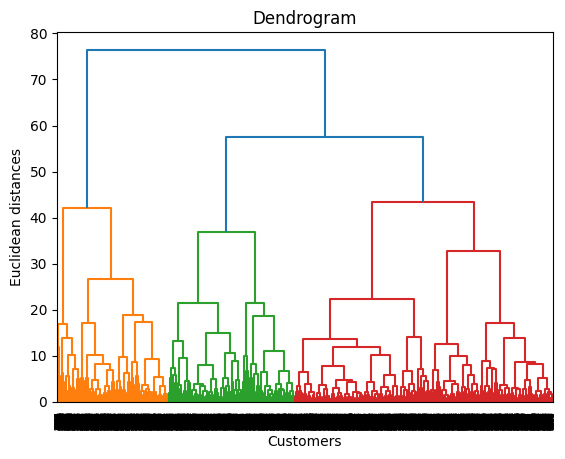

In [19]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X_2, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

# Training the Hierarchical Clustering model on the dataset

## Fitting the Value Stream Hierarchical Model (y_hc1)

In [20]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')
y_hc1 = hc.fit_predict(X_1)

In [21]:
print(y_hc1)

[1 1 1 ... 1 1 1]


## Fitting the Engagement Stream Hierarchical Model (y_hc2)

In [22]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')
y_hc2 = hc.fit_predict(X_2)

In [23]:
print(y_hc2)

[0 0 1 ... 1 1 0]


# Evaluating the Model Performance

## Model Evaluation: Unsupervised Internal Validation Metrics for Value Stream

In [24]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_1, y_hc1)
print("silhouette score")
print(score)

from sklearn.metrics import davies_bouldin_score
dbi = davies_bouldin_score(X_1, y_hc1)
print("davies bouldin score")
print(dbi)

from sklearn.metrics import calinski_harabasz_score
ch = calinski_harabasz_score(X_1, y_hc1)
print("calinski harabasz score")
print(ch)

silhouette score
0.5613325103408011
davies bouldin score
1.0837268002630696
calinski harabasz score
2044.930486329848


## Model Evaluation: Unsupervised Internal Validation Metrics for Engagement Stream

In [25]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_2, y_hc2)
print("silhouette score")
print(score)

from sklearn.metrics import davies_bouldin_score
dbi = davies_bouldin_score(X_2, y_hc2)
print("davies bouldin score")
print(dbi)

from sklearn.metrics import calinski_harabasz_score
ch = calinski_harabasz_score(X_2, y_hc2)
print("calinski harabasz score")
print(ch)

silhouette score
0.2700413175626017
davies bouldin score
1.4188659927205611
calinski harabasz score
1438.0311657843847


# Segment Alignment: Appending Grouping Profiles to Isolated DataFrames

In [26]:
df_value["Value_Cluster"] = y_hc1

df_engagement["Engagement_Cluster"] = y_hc2

# Strategic Fusion: Merging Value and Engagement Clusters for Final Profiling

In [27]:
# Merge the two independent cluster insights together
final_matrix_df = pd.merge(df_value[["Value_Cluster"]], df_engagement[["Engagement_Cluster"]], on="Customer_ID",)

# Show the cross-tabulation table counts
final_matrix = pd.crosstab(final_matrix_df["Value_Cluster"], final_matrix_df["Engagement_Cluster"], margins=True,)

print("=== FINAL REVENUE VS ENGAGEMENT GRID ===")
print(final_matrix)

=== FINAL REVENUE VS ENGAGEMENT GRID ===
Engagement_Cluster     0     1   All
Value_Cluster                       
0                    454   133   587
1                   3417   996  4413
All                 3871  1129  5000


# Compounding Stream Labels into a Unified Segment Feature

In [28]:
# Create the combined segment column using the correct dataframe name
final_matrix_df['Segment'] = ("V" + final_matrix_df['Value_Cluster'].astype(str) + "_E" + final_matrix_df['Engagement_Cluster'].astype(str))

# View the first few rows to see your clean new labels (e.g., V0_E3, V2_E1)
print(final_matrix_df.head(100))

             Value_Cluster  Engagement_Cluster Segment
Customer_ID                                           
CUST_00001               1                   0   V1_E0
CUST_00002               1                   0   V1_E0
CUST_00003               1                   1   V1_E1
CUST_00004               1                   1   V1_E1
CUST_00005               1                   1   V1_E1
...                    ...                 ...     ...
CUST_00096               1                   0   V1_E0
CUST_00097               1                   1   V1_E1
CUST_00098               1                   0   V1_E0
CUST_00099               0                   0   V0_E0
CUST_00100               1                   0   V1_E0

[100 rows x 3 columns]


# Statistical Profiling: Computing Group Means across Business Metrics

In [29]:
# Add the new 'Segment' column directly into your master customer_df
customer_df['Segment'] = final_matrix_df['Segment']

# Group by the new 4-quadrant segments and calculate the means
final_profile = customer_df.groupby('Segment')[['Total_Amount', 'Num_Orders', 'Session_Duration_Minutes', 'Pages_Viewed', 'Recency_Days']].mean()

# Add a column showing exactly how many customers are in each of the 4 quadrants
final_profile['Customer_Count'] = customer_df['Segment'].value_counts()

print("=== FINAL 4-QUADRANT CUSTOMER PROFILE ===")
print(final_profile)

=== FINAL 4-QUADRANT CUSTOMER PROFILE ===
         Total_Amount  Num_Orders  Session_Duration_Minutes  Pages_Viewed  \
Segment                                                                     
V0_E0     8439.855022    3.044053                 14.964370      8.653834   
V0_E1     9117.585188    2.879699                 13.154771     10.216559   
V1_E0     3911.532286    3.597015                 14.981863      8.644514   
V1_E1     3382.543936    3.005020                 13.079730     10.173726   

         Recency_Days  Customer_Count  
Segment                                
V0_E0      133.180617             454  
V0_E1      125.774436             133  
V1_E0      121.309043            3417  
V1_E1      132.406627             996  


# Statistical Distribution: Boxplot Verification of Value Stream Clusters

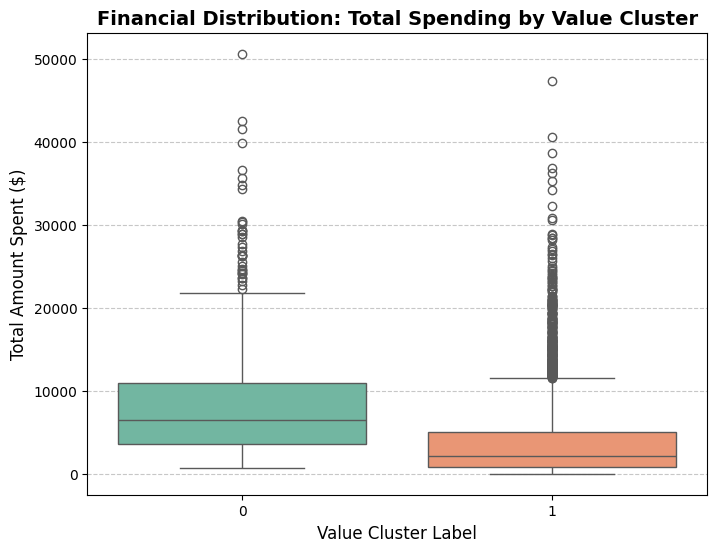

In [36]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(
    x=final_matrix_df["Value_Cluster"],  # Pulls the array directly from your merge dataframe
    y=customer_df["Total_Amount"],       # Pulls the target metric from your master dataframe
    hue=final_matrix_df["Value_Cluster"], # Explicitly mapping hue to remove the deprecation warning
    palette="Set2",
    legend=False                         # Hides the unnecessary redundant legend
)

# Professional visual polishing
plt.title("Financial Distribution: Total Spending by Value Cluster", fontsize=14, fontweight="bold")
plt.xlabel("Value Cluster Label", fontsize=12)
plt.ylabel("Total Amount Spent ($)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

# Agglomerative Clustering Experiments Comparison and Analysis

This project explored multiple customer segmentation strategies using **Agglomerative Clustering** combined with hierarchical analysis to determine the optimal number of customer clusters. Different preprocessing techniques, scaling methods, feature engineering strategies, and customer aggregation approaches were tested to discover the most meaningful and business-oriented customer segments.

The main objective was not only to maximize clustering evaluation metrics, but also to build interpretable and actionable customer segments that reflect both customer value and customer engagement behavior.

---

# 1. Clustering on the Full Transactional Dataset

The first experiments applied Agglomerative Clustering directly on the complete transactional dataset without grouping customers by `Customer_ID`.

This means the clustering algorithm was learning from transaction-level behavior rather than customer-level behavior.

---

## Using StandardScaler

| Metric                  | Result  |
| ----------------------- | ------- |
| Silhouette Score        | 0.3135  |
| Davies-Bouldin Score    | 1.2518  |
| Calinski-Harabasz Score | 9688.74 |

### Analysis

The clustering quality was moderate. The silhouette score indicates that the clusters had some separation, but the transactional nature of the dataset limited the ability to capture long-term customer behavior patterns.

Although the Calinski-Harabasz score was high, this was influenced by the large number of rows in the transactional dataset rather than truly meaningful customer segmentation.

---

## Using RobustScaler

| Metric                  | Result  |
| ----------------------- | ------- |
| Silhouette Score        | 0.6445  |
| Davies-Bouldin Score    | 0.8811  |
| Calinski-Harabasz Score | 8984.10 |

### Analysis

This experiment produced dramatically better results.

The strong silhouette score above `0.64` indicates highly separated clusters with good compactness.

The improvement happened because:

* Transactional data contained many outliers
* Spending behavior was highly skewed
* RobustScaler handled extreme values more effectively than StandardScaler

However, despite the strong metrics, this approach still clustered transactions instead of customers, making the business interpretation less meaningful for customer segmentation purposes.

---

# 2. Customer-Level Aggregation by Customer_ID

The next major improvement was aggregating all transactions by customer.

This transformed the dataset from:

```text id="xhn3fm"
17,049 transaction rows → 5,000 unique customers
```

This approach created stable customer profiles instead of isolated purchases.

---

# 3. Grouped Customer Dataset with All Features

The aggregated dataset included:

* Purchase behavior
* Engagement behavior
* Customer demographics
* Website interaction metrics
* Product diversity
* Recency information

---

## Using StandardScaler

| Metric                  | Result |
| ----------------------- | ------ |
| Silhouette Score        | 0.1273 |
| Davies-Bouldin Score    | 1.8558 |
| Calinski-Harabasz Score | 643.30 |

### Analysis

The clustering quality dropped significantly after combining all features together.

Reasons include:

* Large feature diversity
* Mixed behavioral dimensions
* Numerical overlap between customer groups
* Noise from categorical and demographic information

This experiment showed that simply adding more features does not guarantee better clustering quality.

---

## Using RobustScaler

| Metric                  | Result |
| ----------------------- | ------ |
| Silhouette Score        | 0.4996 |
| Davies-Bouldin Score    | 1.0465 |
| Calinski-Harabasz Score | 933.16 |

### Analysis

RobustScaler substantially improved the clustering performance.

The silhouette score increased from `0.127` to `0.499`, showing that outlier handling was extremely important for customer behavior data.

This experiment demonstrated that customer purchasing patterns contain strong skewness and extreme values.

---

# 4. Removing Categorical Features

The next experiments removed categorical columns to reduce noise and focus only on numerical behavioral patterns.

---

## StandardScaler with Numerical Features Only

| Metric                  | Result |
| ----------------------- | ------ |
| Silhouette Score        | 0.1282 |
| Davies-Bouldin Score    | 2.3588 |
| Calinski-Harabasz Score | 758.75 |

### Analysis

Removing categorical variables alone did not improve clustering quality when using StandardScaler.

The cluster separation remained weak because StandardScaler was still sensitive to outliers and skewed monetary distributions.

---

## RobustScaler with Numerical Features Only (Best Single Dataset Result)

| Metric                  | Result  |
| ----------------------- | ------- |
| Silhouette Score        | 0.6539  |
| Davies-Bouldin Score    | 0.7393  |
| Calinski-Harabasz Score | 1033.98 |

### Cluster Distribution

| Cluster | Customers |
| ------- | --------- |
| 0       | 4915      |
| 1       | 85        |

### Analysis

This experiment achieved the strongest evaluation metrics among all single-model experiments.

The silhouette score above `0.65` indicates extremely strong cluster separation.

However, the clustering result was highly imbalanced:

* One cluster contained almost all customers
* The second cluster contained only 85 customers

This means the algorithm mainly separated:

* normal customers
  from
* extreme high-value customers

Although mathematically strong, this segmentation was not ideal for balanced business segmentation because most customers were grouped into a single cluster.

---

# 5. Separating Value and Engagement Features

This became the most business-oriented and interpretable strategy.

Instead of mixing all customer behaviors together, the dataset was divided into:

## Value Features

Including:

* Total Amount
* Discount Amount
* Quantity
* Number of Orders
* Average Order Value

---

## Engagement Features

Including:

* Session Duration Minutes
* Pages Viewed
* Pages Per Minute
* Customer Rating

---

# 6. Separate Clustering Experiments

---

## StandardScaler with Initial Value and Engagement Features

### Value Dataset

| Metric                  | Result  |
| ----------------------- | ------- |
| Silhouette Score        | 0.3432  |
| Davies-Bouldin Score    | 1.3165  |
| Calinski-Harabasz Score | 2103.51 |

### Engagement Dataset

| Metric                  | Result |
| ----------------------- | ------ |
| Silhouette Score        | 0.1225 |
| Davies-Bouldin Score    | 2.3359 |
| Calinski-Harabasz Score | 540.23 |

### Analysis

The value-based clustering performed reasonably well because spending behavior naturally separates customers more clearly.

However, engagement behavior remained difficult to separate because browsing behavior tends to overlap between customers.

---

## RobustScaler with Initial Value and Engagement Features

### Value Dataset

| Metric                  | Result  |
| ----------------------- | ------- |
| Silhouette Score        | 0.4352  |
| Davies-Bouldin Score    | 1.4920  |
| Calinski-Harabasz Score | 1554.19 |

### Engagement Dataset

| Metric                  | Result |
| ----------------------- | ------ |
| Silhouette Score        | 0.1215 |
| Davies-Bouldin Score    | 2.0060 |
| Calinski-Harabasz Score | 695.02 |

### Analysis

RobustScaler improved the value clustering again because spending data contained strong outliers.

However, engagement clustering still remained challenging.

This confirmed that engagement behavior is naturally less separable than monetary behavior.

---

# 7. Final Selected Experiment (Best Business-Oriented Solution)

The final selected approach used:

## Value Dataset

Features:

* Total Amount
* Discount Amount
* Quantity
* Number of Orders
* Average Order Value

Scaler:

* RobustScaler

Clusters:

* 2

---

## Engagement Dataset

Features:

* Session Duration Minutes
* Pages Viewed
* Pages Per Minute
* Customer Rating

Scaler:

* RobustScaler

Clusters:

* 2

---

# Final Selected Results

## Value Clustering

| Metric                  | Result  |
| ----------------------- | ------- |
| Silhouette Score        | 0.5613  |
| Davies-Bouldin Score    | 1.0837  |
| Calinski-Harabasz Score | 2044.93 |

---

## Engagement Clustering

| Metric                  | Result  |
| ----------------------- | ------- |
| Silhouette Score        | 0.2237  |
| Davies-Bouldin Score    | 1.4126  |
| Calinski-Harabasz Score | 1573.58 |

---

# Why This Final Approach Was Kept

This solution provided the best balance between:

* Strong clustering quality
* Business interpretability
* Balanced customer distribution
* Meaningful customer segmentation

Unlike the earlier experiment with extremely imbalanced clusters, this final approach produced interpretable customer groups that businesses can actually use.

---

# Meaning of the Final Result

The final segmentation created:

```text id="u4p6ud"
2 Value Clusters × 2 Engagement Clusters = 4 Customer Segments
```

This created a clear customer quadrant framework.

---

# Final Customer Segments

| Segment | Meaning                              |
| ------- | ------------------------------------ |
| V0_E0   | High-value low-engagement customers  |
| V0_E1   | High-value high-engagement customers |
| V1_E0   | Low-value low-engagement customers   |
| V1_E1   | Low-value high-engagement customers  |

---

# Final Revenue vs Engagement Grid

| Value Cluster | Engagement Cluster | Customers |
| ------------- | ------------------ | --------- |
| V0_E0         | Low engagement     | 454       |
| V0_E1         | High engagement    | 133       |
| V1_E0         | Low engagement     | 3417      |
| V1_E1         | High engagement    | 996       |

---

# Interpretation of Final Customer Profiles

## V0_E1 — High-Value Highly Engaged Customers

Characteristics:

* Highest spending behavior
* Strong browsing activity
* Better engagement

These are the most valuable customers.

### Business Strategy

* Loyalty programs
* VIP rewards
* Personalized recommendations
* Early product access

---

## V0_E0 — High-Value Low-Engagement Customers

Characteristics:

* High spending
* Lower website interaction

Possible interpretation:

* Fast decision-makers
* Goal-oriented buyers

### Business Strategy

* Retention campaigns
* Personalized communication
* Product reminder systems

---

## V1_E1 — Low-Value Highly Engaged Customers

Characteristics:

* High interaction
* Lower spending behavior

Possible interpretation:

* Interested but price-sensitive customers

### Business Strategy

* Discounts
* Upselling campaigns
* Bundles
* Promotions

---

## V1_E0 — Low-Value Low-Engagement Customers

Characteristics:

* Weak engagement
* Lower revenue contribution

This was the largest customer group.

### Business Strategy

* Re-engagement campaigns
* Marketing incentives
* Retargeting advertisements

---

# Comparison Between Main Experiments

| Experiment                                     | Silhouette Score | Quality                  | Main Issue                                |
| ---------------------------------------------- | ---------------- | ------------------------ | ----------------------------------------- |
| Full transactional dataset with StandardScaler | 0.3135           | Moderate                 | Transaction-level clustering              |
| Full transactional dataset with RobustScaler   | 0.6445           | Excellent mathematically | Not customer-oriented                     |
| Aggregated all features with StandardScaler    | 0.1273           | Weak                     | Feature overlap                           |
| Aggregated all features with RobustScaler      | 0.4996           | Strong                   | Less interpretable                        |
| Numerical features only with RobustScaler      | 0.6539           | Excellent                | Highly imbalanced clusters                |
| Separate value and engagement clustering       | 0.5613           | Best business solution   | Engagement clustering remains challenging |

---

# Key Insights

## 1. RobustScaler Was Significantly Better

Customer behavior data contained:

* Outliers
* Skewed distributions
* Extreme spending patterns

RobustScaler consistently produced stronger clustering quality.

---

## 2. Customer-Level Aggregation Was Essential

Grouping by customer transformed noisy transactional behavior into meaningful customer profiles.

This was one of the most important improvements in the entire project.

---

## 3. Monetary Features Were Easier to Cluster

Value-related behavior consistently achieved much stronger clustering scores than engagement behavior.

This means spending behavior naturally forms clearer customer groups.

---

## 4. Engagement Behavior Was More Complex

Engagement metrics showed lower silhouette scores across nearly all experiments because customer browsing behavior overlaps heavily between users.

---

## 5. Best Mathematical Result Was Not the Best Business Result

The experiment with silhouette score `0.6539` created highly imbalanced clusters:

* 4915 customers
* 85 customers

This was mathematically strong but less useful for real customer segmentation.

The final selected solution achieved a much better balance between performance and practical usability.

---

# Final Conclusion

The project successfully built a complete customer segmentation framework using Agglomerative Clustering and hierarchical analysis.

After testing multiple preprocessing methods, scaling strategies, feature engineering approaches, and clustering structures, the final selected solution was:

* Customer-level aggregation
* Numerical behavioral features
* Separate value and engagement clustering
* RobustScaler preprocessing
* Two value clusters and two engagement clusters

This final framework produced meaningful customer quadrants that can support:

* Customer retention strategies
* Personalized marketing
* Customer lifetime value analysis
* Business intelligence
* Sales optimization
* Engagement improvement strategies

The final segmentation model successfully transformed raw e-commerce data into actionable customer intelligence for real-world business applications.
